Лабораторная работа № 2 по машинному обучению. Работу выполнила: студентка группы 3825М1ФИ2, Шишкина Валерия Алексеевна.

I. Загрузка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('globalterrorismdb_0718dist.xlsx')
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0.0,0.0,0.0,0.0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0.0,1.0,1.0,1.0,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN


In [2]:
print(df.shape)

(181690, 135)


In [3]:
df.describe()

,eventid,iyear,imonth,iday,extended,country,region,specificity,vicinity,crit1,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816900e+05,181690.000000,181690.000000,181690.000000,181690.000000,181690.000000,181690.000000,181684.000000,181690.000000,151574.000000,...,1.041000e+03,3.000000e+02,4.970000e+02,292.000000,6685.000000,6161.000000,138331.000000,138331.000000,138331.000000,138331.000000
mean,2.002705e+11,2002.638956,6.467263,15.505614,0.045346,131.968705,7.160922,1.451454,0.068298,0.987636,...,3.095045e+06,7.145944e+05,5.285444e+05,421.863014,4.520120,-26.340205,-5.065820,-5.015058,0.094599,-4.414874
std,1.325960e+09,13.259456,3.388308,8.814060,0.208063,112.414811,2.933408,0.995432,0.284554,0.110503,...,3.311326e+07,7.787929e+06,2.885991e+06,3995.546426,2.045727,58.016373,4.505124,4.576234,0.620956,4.705112
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,1.000000,-9.000000,0.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,1.000000,0.000000,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,1.000000,0.000000,1.000000,...,1.200000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,-9.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,1.000000,0.000000,1.000000,...,4.515000e+05,0.000000e+00,2.000000e+04,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,5.000000,1.000000,1.000000,...,1.000000e+09,1.320000e+08,4.100000e+07,48000.000000,7.000000,1201.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181690 entries, 0 to 181689
Columns: 135 entries, eventid to related
dtypes: float64(65), int64(8), object(62)
memory usage: 187.1+ MB


II. Обработка данных

Поскольку датасет очень большой и имеет достаточно много признаков, то его необходимо обработать. Логично предположить, что для классификации типов атак необходимо в большей степени обращать внимание на признаки, связанные с тем, где она произошла, в какое время, какова была ее цель, тип оружия.

In [5]:
features_to_use = [
    'iyear', 'imonth', 'iday',
    'country', 'region',
    'latitude', 'longitude',
    'targtype1', 'targsubtype1', 'natlty1',
    'weaptype1', 'weapsubtype1',
    'extended', 'multiple', 'success',
    'suicide', 'ishostkid', 'attacktype1']

In [6]:
X = df[features_to_use].copy()

In [7]:
X

,iyear,imonth,iday,country,region,latitude,longitude,targtype1,targsubtype1,natlty1,weaptype1,weapsubtype1,extended,multiple,success,suicide,ishostkid,attacktype1
0,1970,7,2,58,2,18.456792,-69.951164,14.0,68.0,58.0,13.0,NaN,0,0.0,1.0,0.0,0.0,1.0
1,1970,0,0,130,1,19.371887,-99.086624,7.0,45.0,21.0,13.0,NaN,0,0.0,1.0,0.0,1.0,6.0
2,1970,1,0,160,5,15.478598,120.599741,10.0,54.0,217.0,13.0,NaN,0,0.0,1.0,0.0,0.0,1.0
3,1970,1,0,78,8,37.99749,23.762728,7.0,46.0,217.0,6.0,16.0,0,0.0,1.0,0.0,0.0,3.0
4,1970,1,0,101,4,33.580412,130.396361,7.0,46.0,217.0,8.0,NaN,0,0.0,1.0,0.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181685,2017,12,31,182,11,2.359673,45.385034,4.0,36.0,182.0,5.0,5.0,0,0.0,1.0,0.0,0.0,2.0
181686,2017,12,31,200,10,35.407278,35.942679,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
181687,2017,12,31,160,5,6.900742,124.437908,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
181688,2017,12,31,92,6,24.798346,93.94043,2.0,21.0,92.0,6.0,7.0,0,0.0,0.0,0.0,0.0,3.0


Теперь необходимо поработать с пропущенными значениями. Посмотрим в каких признаках они присутствуют и в каком количестве.

In [8]:
X.isnull().sum()

iyear               0
imonth              0
iday                0
country             0
region              0
latitude         4556
longitude        4557
targtype1       30116
targsubtype1    39130
natlty1         31561
weaptype1       35234
weapsubtype1    51382
extended            0
multiple        30116
success         30116
suicide         30116
ishostkid       38707
attacktype1     30116
dtype: int64

Видно, что 12 признаков из 18 имеют пропущенные значения. Посмотрим на эти признаки.

In [9]:
missing_values = [
    'latitude', 'longitude',
    'targtype1', 'targsubtype1',
    'natlty1', 'weaptype1',
    'weapsubtype1', 'multiple',
    'success', 'suicide',
    'ishostkid', 'attacktype1']

In [10]:
X[missing_values]

,latitude,longitude,targtype1,targsubtype1,natlty1,weaptype1,weapsubtype1,multiple,success,suicide,ishostkid,attacktype1
0,18.456792,-69.951164,14.0,68.0,58.0,13.0,NaN,0.0,1.0,0.0,0.0,1.0
1,19.371887,-99.086624,7.0,45.0,21.0,13.0,NaN,0.0,1.0,0.0,1.0,6.0
2,15.478598,120.599741,10.0,54.0,217.0,13.0,NaN,0.0,1.0,0.0,0.0,1.0
3,37.99749,23.762728,7.0,46.0,217.0,6.0,16.0,0.0,1.0,0.0,0.0,3.0
4,33.580412,130.396361,7.0,46.0,217.0,8.0,NaN,0.0,1.0,0.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...
181685,2.359673,45.385034,4.0,36.0,182.0,5.0,5.0,0.0,1.0,0.0,0.0,2.0
181686,35.407278,35.942679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
181687,6.900742,124.437908,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
181688,24.798346,93.94043,2.0,21.0,92.0,6.0,7.0,0.0,0.0,0.0,0.0,3.0


Для обработки пропущенных значений можно использовать разные методы:
1. Удаление строк, содержащих пропущенные значения - это самый простой способ, но не всегда хороший, потому что если пропущенных значений много, то после их удаления можно потерять очень много полезной информации.
2. Удаление столбцов, если в них много пропущенных значений и ими можно пожертвовать.
3. Замена вычисленными значениями на основе имеющихся данных, например, среднее, мода.
4. Также можно предсказывать пропущенные значения на основе имеющейся информации.

In [11]:
print(X[missing_values].dtypes)

latitude         object
longitude        object
targtype1       float64
targsubtype1    float64
natlty1         float64
weaptype1       float64
weapsubtype1    float64
multiple        float64
success         float64
suicide         float64
ishostkid       float64
attacktype1     float64
dtype: object


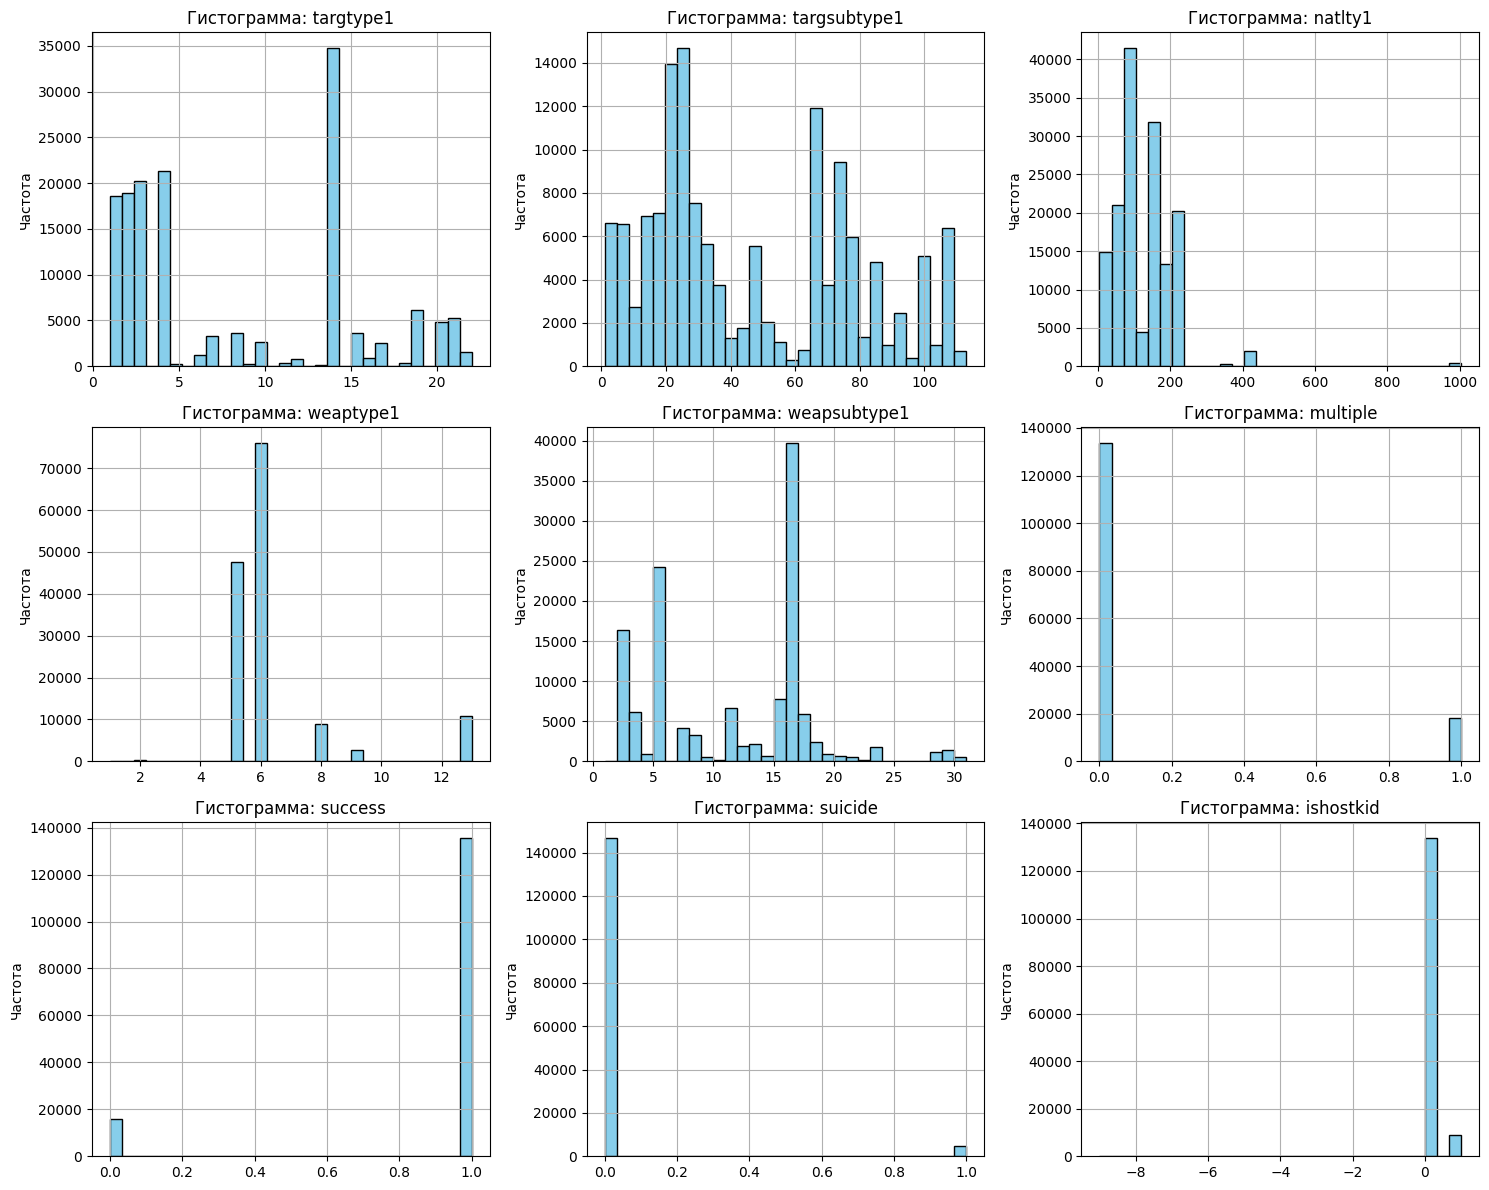

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

missing_values_ = [
    'targtype1', 'targsubtype1',
    'natlty1', 'weaptype1',
    'weapsubtype1', 'multiple',
    'success', 'suicide',
    'ishostkid']

for i, col in enumerate(missing_values_):
    X[col].hist(ax=axes[i], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Гистограмма: {col}')
    axes[i].set_ylabel('Частота')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [13]:
X.isnull().sum()

iyear               0
imonth              0
iday                0
country             0
region              0
latitude         4556
longitude        4557
targtype1       30116
targsubtype1    39130
natlty1         31561
weaptype1       35234
weapsubtype1    51382
extended            0
multiple        30116
success         30116
suicide         30116
ishostkid       38707
attacktype1     30116
dtype: int64

In [14]:
X = X[missing_values].copy()
X['latitude'] = pd.to_numeric(X['latitude'], errors='coerce')
X['longitude'] = pd.to_numeric(X['longitude'], errors='coerce')

X['latitude'] = X['latitude'].fillna(X['latitude'].median())
X['longitude'] = X['longitude'].fillna(X['longitude'].median())

In [16]:
X.isnull().sum()

latitude            0
longitude           0
targtype1       30116
targsubtype1    39130
natlty1         31561
weaptype1       35234
weapsubtype1    51382
multiple        30116
success         30116
suicide         30116
ishostkid       38707
attacktype1     30116
dtype: int64

In [17]:
X['targsubtype1'] = X['targsubtype1'].fillna(-1)
X['natlty1'] = X['natlty1'].fillna(-1)
X['weaptype1'] = X['weaptype1'].fillna(-1)
X['weapsubtype1'] = X['weapsubtype1'].fillna(-1)

X['ishostkid'] = X['ishostkid'].fillna(df['ishostkid'].mode()[0])

In [18]:
X.isnull().sum()

latitude            0
longitude           0
targtype1       30116
targsubtype1        0
natlty1             0
weaptype1           0
weapsubtype1        0
multiple        30116
success         30116
suicide         30116
ishostkid           0
attacktype1     30116
dtype: int64

In [19]:
X = X.dropna(subset=['attacktype1'])

In [20]:
X.isnull().sum()
X

,latitude,longitude,targtype1,targsubtype1,natlty1,weaptype1,weapsubtype1,multiple,success,suicide,ishostkid,attacktype1
0,18.456792,-69.951164,14.0,68.0,58.0,13.0,-1.0,0.0,1.0,0.0,0.0,1.0
1,19.371887,-99.086624,7.0,45.0,21.0,13.0,-1.0,0.0,1.0,0.0,1.0,6.0
2,15.478598,120.599741,10.0,54.0,217.0,13.0,-1.0,0.0,1.0,0.0,0.0,1.0
3,37.997490,23.762728,7.0,46.0,217.0,6.0,16.0,0.0,1.0,0.0,0.0,3.0
4,33.580412,130.396361,7.0,46.0,217.0,8.0,-1.0,0.0,1.0,0.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...
181681,42.888982,13.772795,14.0,65.0,98.0,-1.0,-1.0,0.0,1.0,0.0,0.0,7.0
181684,35.921051,64.774544,1.0,7.0,4.0,6.0,16.0,0.0,1.0,0.0,0.0,3.0
181685,2.359673,45.385034,4.0,36.0,182.0,5.0,5.0,0.0,1.0,0.0,0.0,2.0
181688,24.798346,93.940430,2.0,21.0,92.0,6.0,7.0,0.0,0.0,0.0,0.0,3.0


III. Обучение

In [21]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [22]:
y = X['attacktype1'].copy()
y

0         1.0
1         6.0
2         1.0
3         3.0
4         7.0
         ... 
181681    7.0
181684    3.0
181685    2.0
181688    3.0
181689    3.0
Name: attacktype1, Length: 151574, dtype: float64

In [23]:
X = X.drop(columns='attacktype1')

In [24]:
X

,latitude,longitude,targtype1,targsubtype1,natlty1,weaptype1,weapsubtype1,multiple,success,suicide,ishostkid
0,18.456792,-69.951164,14.0,68.0,58.0,13.0,-1.0,0.0,1.0,0.0,0.0
1,19.371887,-99.086624,7.0,45.0,21.0,13.0,-1.0,0.0,1.0,0.0,1.0
2,15.478598,120.599741,10.0,54.0,217.0,13.0,-1.0,0.0,1.0,0.0,0.0
3,37.997490,23.762728,7.0,46.0,217.0,6.0,16.0,0.0,1.0,0.0,0.0
4,33.580412,130.396361,7.0,46.0,217.0,8.0,-1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
181681,42.888982,13.772795,14.0,65.0,98.0,-1.0,-1.0,0.0,1.0,0.0,0.0
181684,35.921051,64.774544,1.0,7.0,4.0,6.0,16.0,0.0,1.0,0.0,0.0
181685,2.359673,45.385034,4.0,36.0,182.0,5.0,5.0,0.0,1.0,0.0,0.0
181688,24.798346,93.940430,2.0,21.0,92.0,6.0,7.0,0.0,0.0,0.0,0.0


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

In [26]:
X_train.shape, X_test.shape

((121259, 11), (30315, 11))

III. Обучение
1. KNN

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils import shuffle

In [36]:
model_knn = KNeighborsClassifier(n_neighbors=3, p=1)

model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

accuracy_knn = model_knn.score(X_test, y_test)
print(f"Точность kNN: {accuracy_knn:.4f} ({accuracy_knn * 100:.2f}%)")

Точность kNN: 0.8185 (81.85%)


Результат: ~82%, это неплохой результат, но попробуем улучшить.
Построим матрицу ошибок.

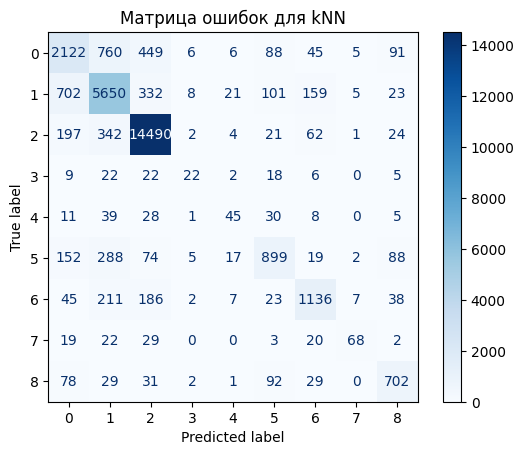

              precision    recall  f1-score   support

         1.0       0.64      0.59      0.61      3572
         2.0       0.77      0.81      0.79      7001
         3.0       0.93      0.96      0.94     15143
         4.0       0.46      0.21      0.29       106
         5.0       0.44      0.27      0.33       167
         6.0       0.71      0.58      0.64      1544
         7.0       0.77      0.69      0.72      1655
         8.0       0.77      0.42      0.54       163
         9.0       0.72      0.73      0.72       964

    accuracy                           0.83     30315
   macro avg       0.69      0.58      0.62     30315
weighted avg       0.82      0.83      0.83     30315



In [42]:
conf_mat_knn = confusion_matrix(y_test, y_pred_knn)

disp_knn = ConfusionMatrixDisplay(confusion_matrix=conf_mat_knn)
disp_knn.plot(cmap='Blues')
plt.title("Матрица ошибок для kNN")
plt.show()

print(classification_report(y_test, y_pred_knn))

In [43]:
model_knn = KNeighborsClassifier(n_neighbors=5, weights='distance', p=1)

model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

accuracy_knn = model_knn.score(X_test, y_test)
print(f"Точность kNN: {accuracy_knn:.4f} ({accuracy_knn * 100:.2f}%)")

Точность kNN: 0.8291 (82.91%)


Попробуем нормализировать данные.

In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_knn = KNeighborsClassifier(n_neighbors=7, weights='distance', p=1)

model_knn.fit(X_train_scaled, y_train)

y_pred_knn = model_knn.predict(X_test_scaled)

accuracy_knn = model_knn.score(X_test_scaled, y_test)
print(f"Точность kNN: {accuracy_knn:.4f} ({accuracy_knn * 100:.2f}%)")

Точность kNN: 0.8631 (86.31%)


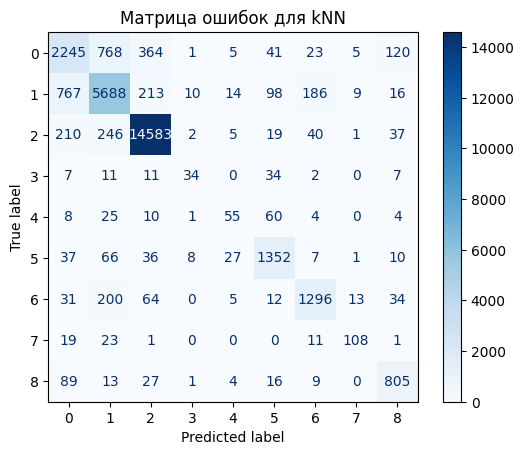

              precision    recall  f1-score   support

         1.0       0.66      0.63      0.64      3572
         2.0       0.81      0.81      0.81      7001
         3.0       0.95      0.96      0.96     15143
         4.0       0.60      0.32      0.42       106
         5.0       0.48      0.33      0.39       167
         6.0       0.83      0.88      0.85      1544
         7.0       0.82      0.78      0.80      1655
         8.0       0.79      0.66      0.72       163
         9.0       0.78      0.84      0.81       964

    accuracy                           0.86     30315
   macro avg       0.75      0.69      0.71     30315
weighted avg       0.86      0.86      0.86     30315



In [52]:
conf_mat_knn = confusion_matrix(y_test, y_pred_knn)

disp_knn = ConfusionMatrixDisplay(confusion_matrix=conf_mat_knn)
disp_knn.plot(cmap='Blues')
plt.title("Матрица ошибок для kNN")
plt.show()

print(classification_report(y_test, y_pred_knn))

2. Random Forest

In [72]:
model_rf = RandomForestClassifier(
    n_estimators=59,
    max_depth=12,
    random_state=52,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

accuracy_rf = model_rf.score(X_test, y_test)
print(f"Точность Random Forest: {accuracy_rf:.4f} ({accuracy_rf * 100:.2f}%)")

Точность Random Forest: 0.8713 (87.13%)


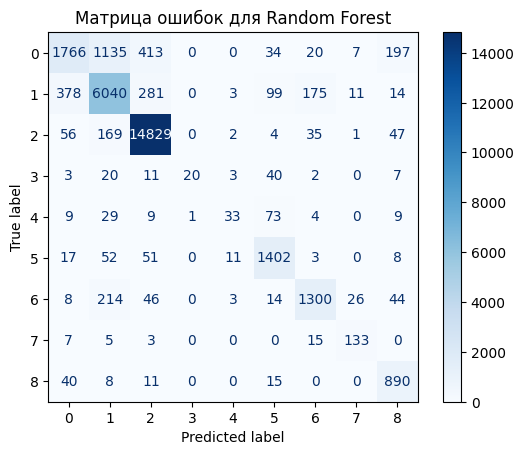

              precision    recall  f1-score   support

         1.0       0.77      0.49      0.60      3572
         2.0       0.79      0.86      0.82      7001
         3.0       0.95      0.98      0.96     15143
         4.0       0.95      0.19      0.31       106
         5.0       0.60      0.20      0.30       167
         6.0       0.83      0.91      0.87      1544
         7.0       0.84      0.79      0.81      1655
         8.0       0.75      0.82      0.78       163
         9.0       0.73      0.92      0.82       964

    accuracy                           0.87     30315
   macro avg       0.80      0.68      0.70     30315
weighted avg       0.87      0.87      0.86     30315



In [81]:
conf_mat_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=conf_mat_rf)
disp_rf.plot(cmap='Blues')
plt.title("Матрица ошибок для Random Forest")
plt.show()

print(classification_report(y_test, y_pred_rf))

3. Extra Trees

In [82]:
model_et = ExtraTreesClassifier(
    n_estimators=50,
    max_depth=12,
    random_state=52,
    n_jobs=-1
)

model_et.fit(X_train, y_train)

y_pred_et = model_et.predict(X_test)

accuracy_et = model_et.score(X_test, y_test)
print(f"Точность Extra Trees: {accuracy_et:.4f} ({accuracy_et * 100:.2f}%)")

Точность Extra Trees: 0.8293 (82.93%)


In [83]:
model_et = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=52,
    n_jobs=-1
)

model_et.fit(X_train, y_train)

y_pred_et = model_et.predict(X_test)

accuracy_et = model_et.score(X_test, y_test)
print(f"Точность Extra Trees: {accuracy_et:.4f} ({accuracy_et * 100:.2f}%)")

Точность Extra Trees: 0.8319 (83.19%)


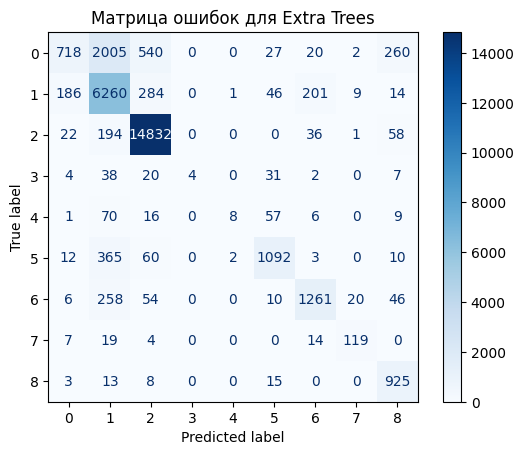

              precision    recall  f1-score   support

         1.0       0.75      0.20      0.32      3572
         2.0       0.68      0.89      0.77      7001
         3.0       0.94      0.98      0.96     15143
         4.0       1.00      0.04      0.07       106
         5.0       0.73      0.05      0.09       167
         6.0       0.85      0.71      0.77      1544
         7.0       0.82      0.76      0.79      1655
         8.0       0.79      0.73      0.76       163
         9.0       0.70      0.96      0.81       964

    accuracy                           0.83     30315
   macro avg       0.81      0.59      0.59     30315
weighted avg       0.84      0.83      0.81     30315



In [84]:
conf_mat_et = confusion_matrix(y_test, y_pred_et)

disp_et = ConfusionMatrixDisplay(confusion_matrix=conf_mat_et)
disp_et.plot(cmap='Blues')
plt.title("Матрица ошибок для Extra Trees")
plt.show()

print(classification_report(y_test, y_pred_et))

4. SVC

In [107]:
model_svc = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    random_state=52
)

model_svc.fit(X_train_scaled, y_train)

y_pred_svc = model_svc.predict(X_test_scaled)

accuracy_svc = model_svc.score(X_test_scaled, y_test)
print(f"Точность SVC: {accuracy_svc:.4f} ({accuracy_svc * 100:.2f}%)")

Точность SVC: 0.7761 (77.61%)


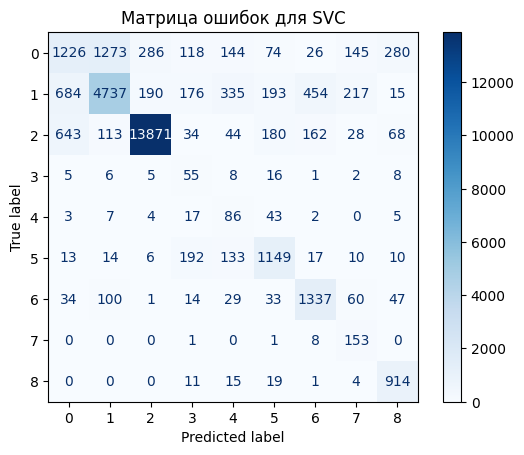

              precision    recall  f1-score   support

         1.0       0.47      0.34      0.40      3572
         2.0       0.76      0.68      0.71      7001
         3.0       0.97      0.92      0.94     15143
         4.0       0.09      0.52      0.15       106
         5.0       0.11      0.51      0.18       167
         6.0       0.67      0.74      0.71      1544
         7.0       0.67      0.81      0.73      1655
         8.0       0.25      0.94      0.39       163
         9.0       0.68      0.95      0.79       964

    accuracy                           0.78     30315
   macro avg       0.52      0.71      0.56     30315
weighted avg       0.81      0.78      0.79     30315



In [108]:
conf_mat_svc = confusion_matrix(y_test, y_pred_svc)
disp_svc = ConfusionMatrixDisplay(confusion_matrix=conf_mat_svc)
disp_svc.plot(cmap='Blues')
plt.title("Матрица ошибок для SVC")
plt.show()

print(classification_report(y_test, y_pred_svc))

In [109]:
import pandas as pd
results = pd.DataFrame({
    'Модель': [
        'KNeighborsClassifier',
        'RandomForestClassifier',
        'ExtraTreesClassifier',
        'SupportVectorClassifier'
    ],
    'Точность (accuracy)': [
        accuracy_knn,
        accuracy_rf,
        accuracy_et,
        accuracy_svc
    ]
})

results['Точность (%)'] = (results['Точность (accuracy)'] * 100).round(2).astype(str) + '%'

results = results.sort_values('Точность (accuracy)', ascending=False).reset_index(drop=True)

print(results[['Модель', 'Точность (%)']].to_string(index=False))

                 Модель Точность (%)
 RandomForestClassifier       87.13%
   KNeighborsClassifier       86.31%
   ExtraTreesClassifier       83.19%
SupportVectorClassifier       77.61%


Наилучшей моделью оказалась RandomForestClassifier, модели KNeighborsClassifier, ExtraTreesClassifier также дают неплохой результат.